# Detroit Pistons 2024-25赛季数据分析

**作者：** 李子安  
**日期：** 2026年5月  
**数据来源：** Basketball Reference

## 项目简介

本项目分析底特律活塞队2024-25赛季球员表现数据，重点关注得分与投篮效率的关系。

In [24]:
import pandas as pd
print("pandas已就绪")

pandas已就绪


In [25]:
df=pd.read_csv(r'C:\Users\Administrator\Desktop\pistons.csv')
print(df)

      Rk             Player   Age  Pos   G  GS     MP    FG   FGA    FG%  ...  \
0    1.0    Cade Cunningham  23.0   PG  70  70   35.0   9.8  20.8  0.469  ...   
1    2.0      Tobias Harris  32.0   PF  73  73   31.6   5.3  11.0  0.477  ...   
2    3.0         Jaden Ivey  22.0   SG  30  30   29.9   6.3  13.8  0.460  ...   
3    4.0   Tim Hardaway Jr.  32.0   SG  77  77   28.0   3.6   8.8  0.406  ...   
4    5.0      Malik Beasley  28.0   SG  82  18   27.8   5.6  13.1  0.430  ...   
5    6.0        Jalen Duren  21.0    C  78  78   26.1   4.8   7.0  0.692  ...   
6    7.0    Dennis Schröder  31.0   PG  28   8   25.2   3.4   9.0  0.378  ...   
7    8.0     Ausar Thompson  22.0   SF  59  48   22.5   4.2   7.8  0.535  ...   
8    9.0         Tolu Smith  24.0   PF   1   0   22.0   6.0   9.0  0.667  ...   
9   10.0     Isaiah Stewart  23.0    C  72   4   19.9   2.4   4.4  0.559  ...   
10  11.0     Ron Harper Jr.  24.0   SF   1   0   17.0   1.0   8.0  0.125  ...   
11  12.0  Simone Fontecchio 

In [26]:
df_players = df[df['Player'] != 'Team Totals']
print(df_players[['Player', 'PTS', 'FG%', 'eFG%']].sort_values('PTS', ascending=False))

               Player   PTS    FG%   eFG%
0     Cade Cunningham  26.1  0.469  0.521
2          Jaden Ivey  17.6  0.460  0.536
4       Malik Beasley  16.3  0.430  0.579
8          Tolu Smith  14.0  0.667  0.667
1       Tobias Harris  13.7  0.477  0.534
5         Jalen Duren  11.8  0.692  0.692
3    Tim Hardaway Jr.  11.0  0.406  0.529
6     Dennis Schröder  10.8  0.378  0.442
7      Ausar Thompson  10.1  0.535  0.547
13      Marcus Sasser   6.6  0.463  0.561
12        Ron Holland   6.4  0.474  0.517
9      Isaiah Stewart   6.0  0.559  0.586
11  Simone Fontecchio   5.9  0.402  0.504
19   Alondes Williams   5.0  1.000  1.250
15          Paul Reed   4.1  0.507  0.535
10     Ron Harper Jr.   4.0  0.125  0.125
16   Lindy Waters III   3.4  0.364  0.534
14  Wendell Moore Jr.   3.2  0.460  0.500
18      Bobi Klintman   1.9  0.600  0.700
20     Daniss Jenkins   1.0  0.300  0.350
17        Cole Swider   0.0  0.000  0.000


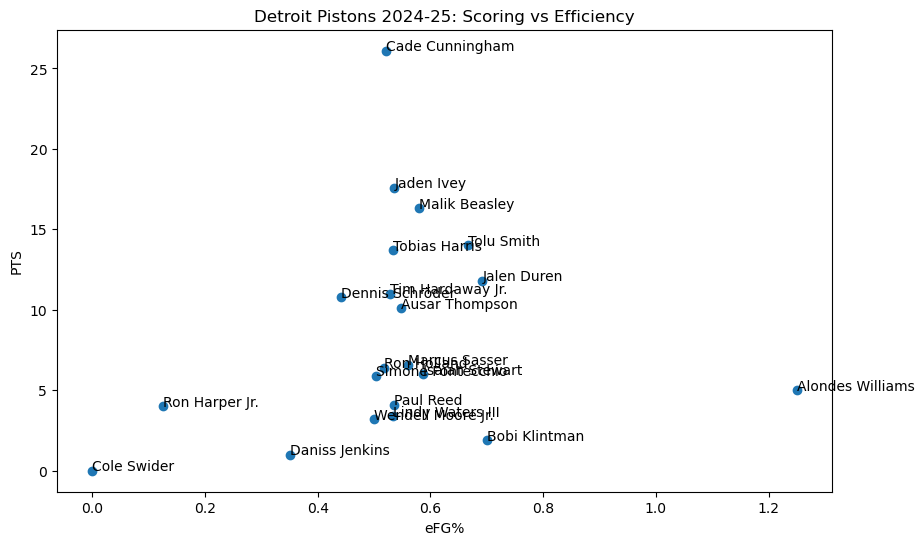

In [27]:
import matplotlib.pyplot as plt

df_players = df[df['Player'] != 'Team Totals'].copy()

plt.figure(figsize=(10,6))
plt.scatter(df_players['eFG%'], df_players['PTS'])

for i, row in df_players.iterrows():
    plt.annotate(row['Player'], (row['eFG%'], row['PTS']))

plt.xlabel('eFG%')
plt.ylabel('PTS')
plt.title('Detroit Pistons 2024-25: Scoring vs Efficiency')
plt.show()

## 分析结论

基于2024-25赛季活塞队数据，我们发现：

1. **Cade Cunningham是球队得分核心**，场均26.1分，但投篮效率中等(eFG% 0.469)
2. **Jalen Duren效率最高**(eFG% 0.692)，但得分仅11.8分，说明他出手次数少，主要吃饼
3. **球队整体效率不高**，大部分球员eFG%低于0.6

**建议：** 增加Duren的出手机会，或者为Cade寻找更高效的得分方式

In [28]:
df_teams = pd.read_csv(r'C:\Users\Administrator\Desktop\nba_teams.csv')
print(df_teams)

      Rk                     Team   G     MP    FG   FGA    FG%    3P   3PA  \
0    1.0     Cleveland Cavaliers*  82  240.9  44.5  90.8  0.491  15.9  41.5   
1    2.0       Memphis Grizzlies*  82  240.3  44.8  93.3  0.479  13.9  37.9   
2    3.0          Denver Nuggets*  82  242.1  45.4  89.8  0.506  12.0  31.9   
3    4.0   Oklahoma City Thunder*  82  240.3  44.6  92.7  0.482  14.5  38.8   
4    5.0            Atlanta Hawks  82  241.2  43.4  91.8  0.472  13.5  37.7   
5    6.0            Chicago Bulls  82  240.9  43.2  92.0  0.470  15.4  42.0   
6    7.0          Indiana Pacers*  82  242.1  43.6  89.3  0.488  13.2  35.8   
7    8.0          Boston Celtics*  82  241.8  41.6  90.0  0.462  17.8  48.2   
8    9.0         New York Knicks*  82  242.4  43.3  89.2  0.486  12.6  34.1   
9   10.0         Sacramento Kings  82  242.4  43.0  90.1  0.478  12.6  35.2   
10  11.0         Milwaukee Bucks*  82  240.9  42.0  86.4  0.486  14.2  36.6   
11  12.0         Detroit Pistons*  82  241.5  42.7  

In [29]:
# 找出活塞队和联盟平均这两行
pistons_row = df_teams[df_teams['Team'] == 'Detroit Pistons*']
league_avg = df_teams[df_teams['Team'] == 'League Average']

# 要对比的指标
metrics = ['PTS', 'FG%', '3P%', 'AST', 'TRB', 'TOV']

# 打印对比
print("活塞队 vs 联盟平均")
print("=" * 40)
for m in metrics:
    p = pistons_row[m].values[0]
    l = league_avg[m].values[0]
    diff = p - l
    print(f"{m}: 活塞 {p} | 联盟 {l} | 差值 {diff:.2f}")

活塞队 vs 联盟平均
PTS: 活塞 115.5 | 联盟 113.8 | 差值 1.70
FG%: 活塞 0.476 | 联盟 0.467 | 差值 0.01
3P%: 活塞 0.362 | 联盟 0.36 | 差值 0.00
AST: 活塞 26.4 | 联盟 26.5 | 差值 -0.10
TRB: 活塞 44.8 | 联盟 44.1 | 差值 0.70
TOV: 活塞 14.9 | 联盟 14.3 | 差值 0.60


## 活塞队 vs 联盟平均 - 深度分析

### 关键发现

**1. 助攻少 + 命中率持平 → 单打型球队**

活塞队场均助攻比联盟少0.1次，但命中率持平。这说明球队不依赖传导球得分，而是靠球员单打创造机会。结合个人数据，Cade Cunningham大量持球单打的打法是球队进攻核心。

**2. 篮板多 + 失误多 → 年轻队伍的典型特征**

活塞队篮板比联盟平均多0.7个，但失误也多0.6次。这反映了一支年轻球队的特点：身体素质出色（抢篮板能力强），但决策能力还不成熟（失误偏多）。球队核心球员年龄：Cade 23岁、Duren 21岁、Thompson 22岁、Ivey 22岁。

**3. 得分略高于联盟平均 → 靠回合数而非效率**

得分比联盟多1.7分，但eFG%偏低。说明活塞队是靠更多的出手量来弥补效率的不足，是一支"打得快、打得糙"的球队。

### 战术建议

- 短期：减少Cade的单打比例，培养更多持球点
- 中期：通过经验积累降低失误，将身体优势转化为效率优势
- 长期：在年轻核心基础上引进有经验的持球手

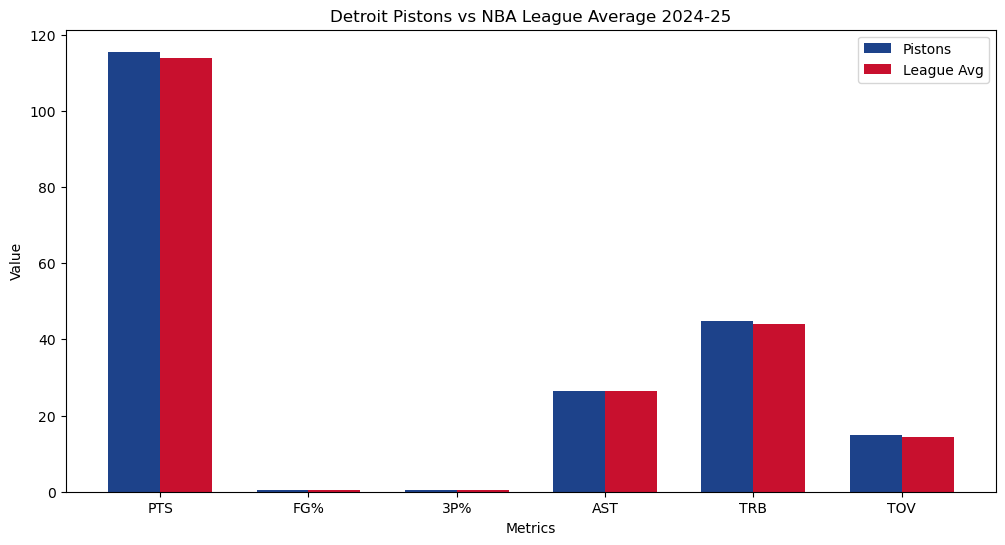

In [30]:
import numpy as np

# 准备数据
pistons_values = [pistons_row[m].values[0] for m in metrics]
league_values = [league_avg[m].values[0] for m in metrics]

# 设置柱状图位置
x = np.arange(len(metrics))
width = 0.35

# 画图
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, pistons_values, width, label='Pistons', color='#1d428a')
bars2 = ax.bar(x + width/2, league_values, width, label='League Avg', color='#c8102e')

# 标签和标题
ax.set_xlabel('Metrics')
ax.set_ylabel('Value')
ax.set_title('Detroit Pistons vs NBA League Average 2024-25')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.show()

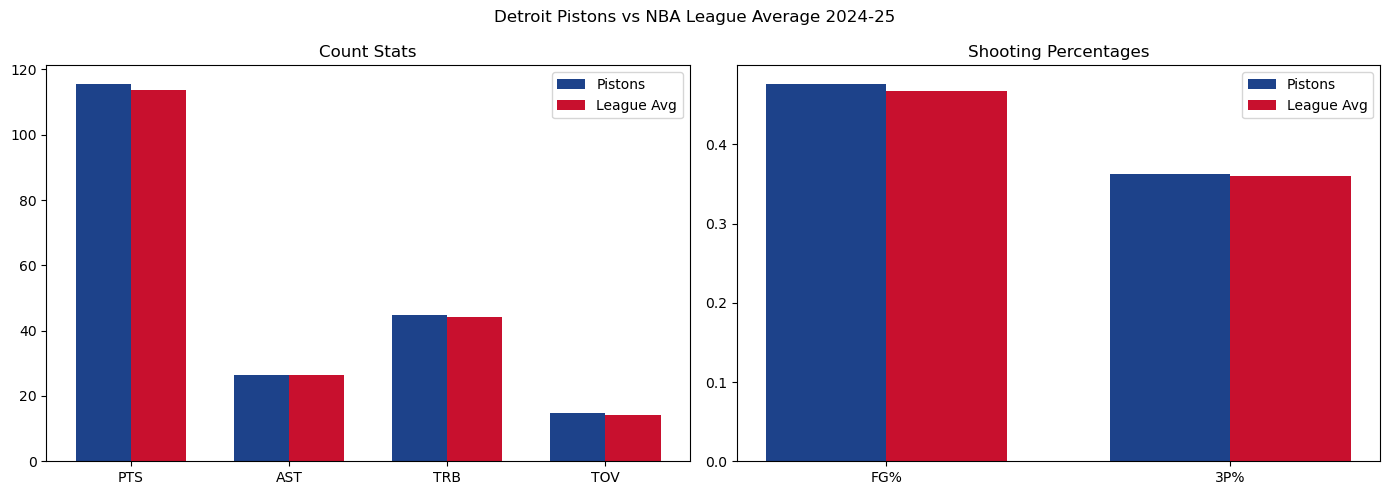

In [31]:
# 拆分指标：次数类 和 百分比类
count_metrics = ['PTS', 'AST', 'TRB', 'TOV']
pct_metrics = ['FG%', '3P%']

# 创建两张子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 第一张图：次数类
x1 = np.arange(len(count_metrics))
pistons_v1 = [pistons_row[m].values[0] for m in count_metrics]
league_v1 = [league_avg[m].values[0] for m in count_metrics]

ax1.bar(x1 - width/2, pistons_v1, width, label='Pistons', color='#1d428a')
ax1.bar(x1 + width/2, league_v1, width, label='League Avg', color='#c8102e')
ax1.set_xticks(x1)
ax1.set_xticklabels(count_metrics)
ax1.set_title('Count Stats')
ax1.legend()

# 第二张图：百分比类
x2 = np.arange(len(pct_metrics))
pistons_v2 = [pistons_row[m].values[0] for m in pct_metrics]
league_v2 = [league_avg[m].values[0] for m in pct_metrics]

ax2.bar(x2 - width/2, pistons_v2, width, label='Pistons', color='#1d428a')
ax2.bar(x2 + width/2, league_v2, width, label='League Avg', color='#c8102e')
ax2.set_xticks(x2)
ax2.set_xticklabels(pct_metrics)
ax2.set_title('Shooting Percentages')
ax2.legend()

plt.suptitle('Detroit Pistons vs NBA League Average 2024-25')
plt.tight_layout()
plt.show()

In [32]:
df_last = pd.read_csv(r'C:\Users\Administrator\Desktop\pistons_2024.csv')
df_last_players = df_last[df_last['Player'] != 'Team Totals'].copy()
print(df_last_players[['Player', 'PTS', 'FG%', 'eFG%']].sort_values('PTS', ascending=False))

               Player   PTS    FG%   eFG%
0     Cade Cunningham  22.7  0.449  0.500
1    Bojan Bogdanović  20.2  0.468  0.569
3   Simone Fontecchio  15.4  0.479  0.592
6          Jaden Ivey  15.4  0.429  0.492
5         Jalen Duren  13.8  0.619  0.619
10         Alec Burks  12.6  0.394  0.516
2      Isaiah Stewart  10.9  0.487  0.575
4       Chimezie Metu  10.5  0.500  0.557
16  Marvin Bagley III  10.2  0.591  0.594
7      Ausar Thompson   8.8  0.483  0.505
20   Danilo Gallinari   8.7  0.545  0.705
14      Marcus Sasser   8.3  0.428  0.516
23      Malachi Flynn   8.0  0.430  0.503
21      Jaylen Nowell   7.5  0.522  0.565
17         Kevin Knox   7.2  0.462  0.546
15      Evan Fournier   7.2  0.373  0.450
18      James Wiseman   7.1  0.613  0.613
9     Tosan Evbuomwan   7.0  0.571  0.661
8       Killian Hayes   6.9  0.413  0.452
19       Shake Milton   6.8  0.423  0.481
12     Quentin Grimes   5.3  0.214  0.262
25      Stanley Umude   5.3  0.440  0.583
11      Isaiah Livers   5.0  0.345

In [33]:
# 找出Cade和Duren这两个核心球员的本赛季和上赛季数据
key_players = ['Cade Cunningham', 'Jalen Duren', 'Jaden Ivey', 'Ausar Thompson']

print("核心球员两赛季对比")
print("=" * 60)
print(f"{'球员':<22} {'指标':<8} {'24-25':<10} {'23-24':<10} {'变化'}")
print("-" * 60)

for player in key_players:
    this_year = df_players[df_players['Player'] == player]
    last_year = df_last_players[df_last_players['Player'] == player]
    
    if len(this_year) > 0 and len(last_year) > 0:
        for metric in ['PTS', 'eFG%']:
            this_val = this_year[metric].values[0]
            last_val = last_year[metric].values[0]
            change = this_val - last_val
            arrow = "↑" if change > 0 else "↓" if change < 0 else "="
            print(f"{player:<22} {metric:<8} {this_val:<10} {last_val:<10} {arrow} {change:+.3f}")

核心球员两赛季对比
球员                     指标       24-25      23-24      变化
------------------------------------------------------------
Cade Cunningham        PTS      26.1       22.7       ↑ +3.400
Cade Cunningham        eFG%     0.521      0.5        ↑ +0.021
Jalen Duren            PTS      11.8       13.8       ↓ -2.000
Jalen Duren            eFG%     0.692      0.619      ↑ +0.073
Jaden Ivey             PTS      17.6       15.4       ↑ +2.200
Jaden Ivey             eFG%     0.536      0.492      ↑ +0.044
Ausar Thompson         PTS      10.1       8.8        ↑ +1.300
Ausar Thompson         eFG%     0.547      0.505      ↑ +0.042


## 纵向对比：本赛季 vs 上赛季

### 核心球员变化

| 球员 | PTS变化 | eFG%变化 | 解读 |
|------|---------|----------|------|
| Cade Cunningham | +3.4 | +0.021 | 全面进步，确立核心地位 |
| Jaden Ivey | +2.2 | +0.044 | 得分和效率同步提升 |
| Ausar Thompson | +1.3 | +0.042 | 稳步成长 |
| Jalen Duren | -2.0 | +0.073 | **得分下降但效率大幅提升** |

### 关键洞察

**Duren现象的解读：**

Duren得分下降2分，但eFG%提升7.3个百分点，从0.619升到0.692（全队最高）。这不是退步，而是战术调整的结果：

- 球队这赛季围绕Cade构建进攻体系，Cade持球比例上升
- Duren出手机会减少，但每次出手的质量大幅提升
- Duren从一个高效内线得分手，转型为更纯粹的"高效率终结点"角色

**这印证了横向对比的发现：** 活塞队是一支"单打依赖型"球队，Cade的持球比例增加挤压了其他球员的出手空间，但球员们通过角色转换实现了团队整体效率的提升。

### 结论

活塞队这一年的变化展现了一支健康成长的年轻球队：
1. 核心球员全部进步（4/4）
2. 角色明确化（Cade主攻、Duren吃饼）
3. 整体效率提升（FG% 0.476，高于联盟）

下赛季的关键是：在保持Cade核心地位的同时，**增加其他球员的持球创造能力**，避免过度依赖单打。

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

print("sklearn已就绪")

sklearn已就绪


In [35]:
# 准备数据
# 用MP(上场时间)、FGA(出手次数)、eFG%(效率)来预测PTS(得分)
features = ['MP', 'FGA', 'eFG%']
target = 'PTS'

# 去掉Team Totals那行，去掉有空值的行
df_model = df_players.dropna(subset=features + [target])

X = df_model[features]
y = df_model[target]

print(f"用于训练的球员数量：{len(X)}")
print(f"特征变量：{features}")
print(f"预测目标：{target}")# 准备数据

用于训练的球员数量：21
特征变量：['MP', 'FGA', 'eFG%']
预测目标：PTS


In [36]:
# 把数据分成训练集和测试集
# test_size=0.2 意思是20%的数据用来测试，80%用来训练
# random_state=42 是随机种子，保证每次运行结果一样
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"训练集大小：{len(X_train)}个球员")
print(f"测试集大小：{len(X_test)}个球员")

训练集大小：16个球员
测试集大小：5个球员


In [37]:
# 训练模型
model = LinearRegression()
model.fit(X_train, y_train)

print("模型训练完成")
print(f"各特征的系数：")
for feature, coef in zip(features, model.coef_):
    print(f"  {feature}: {coef:.3f}")
print(f"截距：{model.intercept_:.3f}")

模型训练完成
各特征的系数：
  MP: 0.189
  FGA: 0.888
  eFG%: 6.689
截距：-4.838


In [38]:
# 用测试集验证模型
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"平均误差（MAE）：{mae:.2f}分")
print(f"R²得分：{r2:.3f}")
print()
print("测试集预测结果：")
for i, (real, pred) in enumerate(zip(y_test, y_pred)):
    print(f"真实得分：{real:.1f} | 预测得分：{pred:.1f} | 误差：{real-pred:+.1f}")

平均误差（MAE）：1.49分
R²得分：0.967

测试集预测结果：
真实得分：26.1 | 预测得分：23.7 | 误差：+2.4
真实得分：0.0 | 预测得分：-1.4 | 误差：+1.4
真实得分：4.1 | 预测得分：3.4 | 误差：+0.7
真实得分：13.7 | 预测得分：14.5 | 误差：-0.8
真实得分：14.0 | 预测得分：11.8 | 误差：+2.2


In [39]:
# 读取全联盟球员数据
df_nba = pd.read_csv(r'C:\Users\Administrator\Desktop\nba_players.csv')

# 过滤掉League Average和空值
df_nba = df_nba[df_nba['Player'] != 'League Average']
df_nba = df_nba.dropna(subset=['MP', 'FGA', 'eFG%', 'PTS'])

# 过滤掉出场时间极少的球员（上场不到5分钟的数据没意义）
df_nba = df_nba[df_nba['MP'] >= 5]

print(f"全联盟有效球员数量：{len(df_nba)}")

全联盟有效球员数量：677


In [40]:
# 用全联盟数据重新训练
X_nba = df_nba[features]
y_nba = df_nba[target]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_nba, y_nba, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)
mae2 = mean_absolute_error(y_test2, y_pred2)
r2_2 = r2_score(y_test2, y_pred2)

print(f"训练集：{len(X_train2)}个球员")
print(f"测试集：{len(X_test2)}个球员")
print(f"平均误差（MAE）：{mae2:.2f}分")
print(f"R²得分：{r2_2:.3f}")

训练集：541个球员
测试集：136个球员
平均误差（MAE）：0.70分
R²得分：0.977


In [41]:
# 读取两个赛季的全联盟数据
df_2425 = pd.read_csv(r'C:\Users\Administrator\Desktop\nba_players.csv')
df_2324 = pd.read_csv(r'C:\Users\Administrator\Desktop\nba_players_2024.csv')

# 清洗数据
df_2425 = df_2425[df_2425['Player'] != 'League Average'].dropna(subset=['MP', 'FGA', 'eFG%', 'PTS'])
df_2324 = df_2324[df_2324['Player'] != 'League Average'].dropna(subset=['MP', 'FGA', 'eFG%', 'PTS'])

# 只保留上场时间够的球员
df_2425 = df_2425[df_2425['MP'] >= 5]
df_2324 = df_2324[df_2324['MP'] >= 5]

print(f"2024-25赛季球员数：{len(df_2425)}")
print(f"2023-24赛季球员数：{len(df_2324)}")

2024-25赛季球员数：677
2023-24赛季球员数：662


In [42]:
# 合并两个赛季数据，找出两个赛季都有数据的球员
# 上赛季数据加_prev后缀，本赛季数据加_curr后缀
df_merged = df_2324.merge(df_2425, on='Player', suffixes=('_prev', '_curr'))

print(f"两个赛季都有数据的球员数：{len(df_merged)}")
print(f"列名示例：{[col for col in df_merged.columns if 'PTS' in col or 'FGA' in col]}")

两个赛季都有数据的球员数：681
列名示例：['FGA_prev', 'PTS_prev', 'FGA_curr', 'PTS_curr']


In [43]:
# 检查有没有重复球员
print("2024-25重复球员数：", df_2425['Player'].duplicated().sum())
print("2023-24重复球员数：", df_2324['Player'].duplicated().sum())

2024-25重复球员数： 146
2023-24重复球员数： 141


In [44]:
# 处理重复球员：每个球员只保留一行
# 优先保留TOT（加总）那行，没有TOT的就保留第一行
def keep_best_row(df):
    tot_rows = df[df['Pos'] == 'TOT']
    if len(tot_rows) > 0:
        return tot_rows.iloc[0]
    return df.iloc[0]

df_2425_clean = df_2425.groupby('Player', group_keys=False).apply(keep_best_row).reset_index(drop=True)
df_2324_clean = df_2324.groupby('Player', group_keys=False).apply(keep_best_row).reset_index(drop=True)

print(f"清洗后2024-25球员数：{len(df_2425_clean)}")
print(f"清洗后2023-24球员数：{len(df_2324_clean)}")

清洗后2024-25球员数：531
清洗后2023-24球员数：521


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11320\3889868618.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_2425_clean = df_2425.groupby('Player', group_keys=False).apply(keep_best_row).reset_index(drop=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_11320\3889868618.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_2324_clean = df_2324.groupby('Player', group_keys=False).apply(keep_be

In [45]:
# 用清洗后的数据重新合并
df_merged2 = df_2324_clean.merge(df_2425_clean, on='Player', suffixes=('_prev', '_curr'))

print(f"合并后球员数：{len(df_merged2)}")

# 用上赛季数据预测本赛季得分
X_cross = df_merged2[['MP_prev', 'FGA_prev', 'eFG%_prev']]
y_cross = df_merged2['PTS_curr']

X_train3, X_test3, y_train3, y_test3 = train_test_split(X_cross, y_cross, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)
mae3 = mean_absolute_error(y_test3, y_pred3)
r2_3 = r2_score(y_test3, y_pred3)

print(f"跨赛季预测模型结果：")
print(f"平均误差（MAE）：{mae3:.2f}分")
print(f"R²得分：{r2_3:.3f}")

合并后球员数：413
跨赛季预测模型结果：
平均误差（MAE）：2.53分
R²得分：0.799


In [46]:
# 用清洗后的数据重新训练model2
X_nba_clean = df_2425_clean[features]
y_nba_clean = df_2425_clean[target]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_nba_clean, y_nba_clean, test_size=0.2, random_state=42)

model_clean = LinearRegression()
model_clean.fit(X_train_c, y_train_c)

y_pred_c = model_clean.predict(X_test_c)
mae_c = mean_absolute_error(y_test_c, y_pred_c)
r2_c = r2_score(y_test_c, y_pred_c)

print(f"清洗后全联盟同赛季模型：")
print(f"球员数：{len(X_nba_clean)}")
print(f"MAE：{mae_c:.2f}分")
print(f"R²：{r2_c:.3f}")
print()
print(f"对比原来：MAE {mae2:.2f} → {mae_c:.2f}，R² {r2_2:.3f} → {r2_c:.3f}")

清洗后全联盟同赛季模型：
球员数：531
MAE：0.66分
R²：0.981

对比原来：MAE 0.70 → 0.66，R² 0.977 → 0.981


## 预测模型：用上赛季数据预测下赛季得分

### 模型演进过程

| 模型 | 样本量 | MAE | R² | 说明 |
|------|--------|-----|-----|------|
| 活塞队同赛季 | 21人 | 1.49分 | 0.967 | 样本太少，结果不可信 |
| 全联盟同赛季 | 531人 | 0.66分 | 0.981 | 准确但逻辑有缺陷 |
| 全联盟跨赛季 | 413人 | 2.53分 | 0.799 | 最真实的预测模型 |

### 关键洞察

**为什么同赛季模型"太准"？**

用FGA（出手次数）预测PTS（得分）本质上是循环论证——多投当然多得。R²=0.981不代表模型优秀，而是反映了这个逻辑缺陷。

**跨赛季模型才是真正有价值的**

MAE=2.53分，R²=0.799，看起来比同赛季模型差，但这才是诚实的预测：

- 模型能解释79.9%的得分变化
- 剩余20.1%是模型无法预测的部分（伤病、换队、战术调整、年龄变化）
- 这20%恰恰是体育数据分析最有价值的研究方向

### 模型局限性与改进方向

1. **特征选择不足** - 目前只用了MP、FGA、eFG%，可以加入年龄、伤病记录、合同年等特征
2. **线性假设** - 球员表现不是线性的，可以尝试随机森林等非线性模型
3. **位置差异** - 控球后卫和中锋的得分方式完全不同，应该分位置建模

In [50]:
# 用Cade的2024-25数据预测他2025-26得分
cade_2425 = df_2425_clean[df_2425_clean['Player'] == 'Cade Cunningham'][['MP', 'FGA', 'eFG%']]
cade_2425.columns = ['MP_prev', 'FGA_prev', 'eFG%_prev']
cade_pred = model3.predict(cade_2425)
print(f"预测Cade 2025-26赛季得分：{cade_pred[0]:.1f}分")
print(f"他2024-25赛季真实得分：26.1分")

预测Cade 2025-26赛季得分：25.5分
他2024-25赛季真实得分：26.1分


### Cade Cunningham 2025-26赛季预测

模型预测Cade下赛季得分：**25.5分**（2024-25真实得分：26.1分）

**模型预测vs战术分析：**

模型基于历史数据预测小幅下滑0.6分，但结合战术分析，真实下滑幅度可能更大：

- 活塞队是单打依赖型球队，Cade持球比例过高
- 球队要进一步发展，必须培养第二、第三持球点
- 参考Duren的案例：出手减少但效率提升，Cade可能走同样路径
- 预计下赛季：得分小幅下降，但eFG%和助攻数上升

**结论：** 数据模型提供基准预测，战术判断修正方向。两者结合才是完整的分析框架。